In [23]:
!pip install -U langgraph langchain langchain-google-genai langchain-chroma chromadb

In [24]:
import os
import json
import operator
from typing import TypedDict, Annotated, List, Dict, Any, Literal

from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver


In [25]:
import os
from google import genai
from google.colab import userdata

#API_KEY = put the new api key here created latest
api_key = userdata.get("GOOGLE_API_KEY")
#client = genai.Client(api_key=api_key)
os.environ["GOOGLE_API_KEY"] = api_key
# ---------------------------------------
# 1. API KEY
# ---------------------------------------
# In Colab:
# import getpass
# os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter Gemini API key: ")

if "GOOGLE_API_KEY" not in os.environ:
    raise ValueError("Please set GOOGLE_API_KEY first.")

In [26]:
!pip install -U sentence-transformers langchain-huggingface

In [27]:
from langchain_huggingface import HuggingFaceEmbeddings

In [28]:
# ---------------------------------------
# 2. BUILD SMALL AUTOMOTIVE KNOWLEDGE BASE
# ---------------------------------------
docs = [
    Document(
        page_content="""
        Engine overheating diagnosis:
        If coolant temperature is above 105 C, check coolant level, radiator fan,
        thermostat, coolant pump, radiator blockage, and coolant leakage.
        If temperature is above 115 C, vehicle must be stopped safely.
        """,
        metadata={"topic": "engine_cooling"}
    ),
    Document(
        page_content="""
        Brake pressure safety:
        Normal brake hydraulic pressure should generally remain above safe threshold.
        If brake pressure falls below 55 bar, braking performance may be compromised.
        If brake pressure is critically low, escalate immediately and advise driver to stop.
        """,
        metadata={"topic": "brake_safety"}
    ),
    Document(
        page_content="""
        Immobilization policy:
        Immobilize only when the condition is safety critical and human approval is given,
        or when autonomous emergency policy permits immobilization after the vehicle reaches
        a safe stop condition.
        """,
        metadata={"topic": "immobilization"}
    ),
    Document(
        page_content="""
        Low diagnostic confidence:
        If confidence is below 0.70, retrieve additional maintenance documents and repeat diagnosis.
        Confidence improves when multiple symptoms match the same fault family.
        """,
        metadata={"topic": "confidence_policy"}
    ),
]

embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vector_db = Chroma.from_documents(
    documents=docs,
    embedding=embedding,
    collection_name="automotive_telemetry_kb",
    persist_directory="./chroma_auto_telemetry"
)

retriever = vector_db.as_retriever(search_kwargs={"k": 2})

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [29]:
# ---------------------------------------
# 3. GEMINI LLM
# ---------------------------------------
llm = ChatGoogleGenerativeAI(
    model="gemini-1.5-flash",
    temperature=0.2,
    max_retries=0
)


In [30]:
# ---------------------------------------
# 4. LANGGRAPH STATE
# ---------------------------------------
class TelemetryState(TypedDict):
    vehicle_id: str
    telemetry: Dict[str, Any]

    risk_flags: List[str]
    route: str

    retrieved_docs: Annotated[List[str], operator.add]
    diagnosis: str
    confidence: float

    retry_count: int
    safety_critical: bool

    human_approval_required: bool
    human_approved: bool

    action: str
    final_report: str

    state_log: Annotated[List[str], operator.add]


In [32]:
# ---------------------------------------
# 5. HELPER
# ---------------------------------------
def log(message: str) -> List[str]:
    return [message]


# ---------------------------------------
# 6. NODE: STORE INITIAL STATE
# ---------------------------------------
def store_vehicle_state(state: TelemetryState):
    snapshot = {
        "vehicle_id": state["vehicle_id"],
        "telemetry": state["telemetry"]
    }
    return {
        "state_log": log(f"Stored initial vehicle state: {json.dumps(snapshot)}")
    }


# ---------------------------------------
# 7. NODE: ANALYZE TELEMETRY
# ---------------------------------------
def analyze_telemetry(state: TelemetryState):
    t = state["telemetry"]
    flags = []

    if t["engine_temp_c"] >= 105:
        flags.append("ENGINE_TEMP_HIGH")

    if t["brake_pressure_bar"] < 55:
        flags.append("BRAKE_PRESSURE_LOW")

    if t["vehicle_speed_kmph"] > 0 and t["brake_pressure_bar"] < 45:
        flags.append("DANGEROUS_BRAKE_WHILE_MOVING")

    safety_critical = (
        "DANGEROUS_BRAKE_WHILE_MOVING" in flags
        or t["engine_temp_c"] >= 115
        or t["brake_pressure_bar"] < 40
    )

    return {
        "risk_flags": flags,
        "safety_critical": safety_critical,
        "state_log": log(f"Telemetry analyzed. Flags={flags}, safety_critical={safety_critical}")
    }


# ---------------------------------------
# 8. ROUTER: CHOOSE DIAGNOSIS PATH
# ---------------------------------------
def route_by_fault(state: TelemetryState) -> Literal["cooling", "brake", "general"]:
    flags = state["risk_flags"]

    if "BRAKE_PRESSURE_LOW" in flags or "DANGEROUS_BRAKE_WHILE_MOVING" in flags:
        return "brake"

    if "ENGINE_TEMP_HIGH" in flags:
        return "cooling"

    return "general"


# ---------------------------------------
# 9. NODE: COOLING RETRIEVAL
# ---------------------------------------
def retrieve_cooling_docs(state: TelemetryState):
    query = "engine overheating coolant radiator fan thermostat diagnosis"
    results = retriever.invoke(query)
    return {
        "route": "cooling",
        "retrieved_docs": [d.page_content for d in results],
        "state_log": log("Retrieved cooling-system documents.")
    }


# ---------------------------------------
# 10. NODE: BRAKE RETRIEVAL
# ---------------------------------------
def retrieve_brake_docs(state: TelemetryState):
    query = "low brake pressure hydraulic brake safety escalation immobilization"
    results = retriever.invoke(query)
    return {
        "route": "brake",
        "retrieved_docs": [d.page_content for d in results],
        "state_log": log("Retrieved brake-safety documents.")
    }


# ---------------------------------------
# 11. NODE: GENERAL RETRIEVAL
# ---------------------------------------
def retrieve_general_docs(state: TelemetryState):
    query = "general automotive telemetry diagnosis"
    results = retriever.invoke(query)
    return {
        "route": "general",
        "retrieved_docs": [d.page_content for d in results],
        "state_log": log("Retrieved general documents.")
    }


# ---------------------------------------
# 12. NODE: LLM DIAGNOSIS WITH RETRY STATE
# ---------------------------------------
def llm_diagnosis(state: TelemetryState):
    prompt = f"""
You are an automotive diagnostic assistant.

Telemetry:
{json.dumps(state["telemetry"], indent=2)}

Risk flags:
{state["risk_flags"]}

Retrieved maintenance context:
{chr(10).join(state["retrieved_docs"])}

Give output ONLY as JSON:
{{
  "diagnosis": "...",
  "confidence": 0.0,
  "recommended_action": "..."
}}

Rules:
- If brake pressure is low, mention safety escalation.
- If engine temperature is high, mention cooling system diagnosis.
- If vehicle is dangerous, recommend safe stop and immobilization approval.
"""

    try:
        response = llm.invoke(prompt)
        raw = response.content.strip()

        raw = raw.replace("```json", "").replace("```", "").strip()
        parsed = json.loads(raw)

        return {
            "diagnosis": parsed.get("diagnosis", "No diagnosis produced."),
            "confidence": float(parsed.get("confidence", 0.5)),
            "action": parsed.get("recommended_action", "No action."),
            "state_log": log("LLM diagnosis completed.")
        }

    except Exception as e:
        return {
            "retry_count": state["retry_count"] + 1,
            "diagnosis": f"LLM failed: {str(e)}",
            "confidence": 0.0,
            "state_log": log(f"LLM failure. Retry count={state['retry_count'] + 1}")
        }




In [33]:
# ---------------------------------------
# 13. ROUTER: RETRY, RETRIEVE MORE, HUMAN APPROVAL, OR REPORT
# ---------------------------------------
def post_diagnosis_router(
    state: TelemetryState
) -> Literal["retry_llm", "retrieve_more", "human_approval", "report"]:

    if state["confidence"] == 0.0 and state["retry_count"] < 2:
        return "retry_llm"

    if state["confidence"] < 0.70 and state["retry_count"] < 3:
        return "retrieve_more"

    if state["safety_critical"]:
        return "human_approval"

    return "report"


# ---------------------------------------
# 14. NODE: RETRIEVE MORE DOCUMENTS IF CONFIDENCE LOW
# ---------------------------------------
def retrieve_more_docs(state: TelemetryState):
    query = f"""
    More details for diagnostic uncertainty.
    Flags: {state["risk_flags"]}
    Telemetry: {state["telemetry"]}
    """
    results = retriever.invoke(query)

    return {
        "retry_count": state["retry_count"] + 1,
        "retrieved_docs": [d.page_content for d in results],
        "state_log": log("Confidence low. Retrieved more documents and looping back to LLM.")
    }


# ---------------------------------------
# 15. NODE: HUMAN APPROVAL
# ---------------------------------------
def human_approval_node(state: TelemetryState):
    print("\nSAFETY CRITICAL CONDITION DETECTED")
    print("Vehicle:", state["vehicle_id"])
    print("Telemetry:", state["telemetry"])
    print("Diagnosis:", state["diagnosis"])
    print("Recommended action:", state["action"])

    user_input = input("\nApprove immobilization? Type YES or NO: ").strip().upper()
    approved = user_input == "YES"

    return {
        "human_approval_required": True,
        "human_approved": approved,
        "state_log": log(f"Human approval captured: {approved}")
    }



In [34]:

# ---------------------------------------
# 16. ROUTER: IMMOBILIZE OR REPORT
# ---------------------------------------
def approval_router(state: TelemetryState) -> Literal["immobilize", "report"]:
    if state["human_approved"]:
        return "immobilize"
    return "report"


# ---------------------------------------
# 17. NODE: IMMOBILIZE VEHICLE
# ---------------------------------------
def immobilize_vehicle(state: TelemetryState):
    return {
        "action": "IMMOBILIZE VEHICLE AFTER SAFE STOP. Notify fleet control and service team.",
        "state_log": log("Vehicle immobilization command issued.")
    }


# ---------------------------------------
# 18. NODE: FINAL REPORT
# ---------------------------------------
def final_report(state: TelemetryState):
    report = f"""
AUTOMOTIVE TELEMETRY DIAGNOSTIC REPORT

Vehicle ID: {state["vehicle_id"]}

Telemetry:
{json.dumps(state["telemetry"], indent=2)}

Risk Flags:
{state["risk_flags"]}

Diagnosis:
{state["diagnosis"]}

Confidence:
{state["confidence"]}

Safety Critical:
{state["safety_critical"]}

Human Approval Required:
{state["human_approval_required"]}

Human Approved:
{state["human_approved"]}

Final Action:
{state["action"]}

Execution Log:
{chr(10).join(state["state_log"])}
"""
    return {
        "final_report": report,
        "state_log": log("Final report generated.")
    }



In [35]:

# ---------------------------------------
# 19. BUILD LANGGRAPH
# ---------------------------------------
graph_builder = StateGraph(TelemetryState)

graph_builder.add_node("store_vehicle_state", store_vehicle_state)
graph_builder.add_node("analyze_telemetry", analyze_telemetry)
graph_builder.add_node("retrieve_cooling_docs", retrieve_cooling_docs)
graph_builder.add_node("retrieve_brake_docs", retrieve_brake_docs)
graph_builder.add_node("retrieve_general_docs", retrieve_general_docs)
graph_builder.add_node("llm_diagnosis", llm_diagnosis)
graph_builder.add_node("retrieve_more_docs", retrieve_more_docs)
graph_builder.add_node("human_approval_node", human_approval_node)
graph_builder.add_node("immobilize_vehicle", immobilize_vehicle)
graph_builder.add_node("final_report", final_report)

graph_builder.add_edge(START, "store_vehicle_state")
graph_builder.add_edge("store_vehicle_state", "analyze_telemetry")

graph_builder.add_conditional_edges(
    "analyze_telemetry",
    route_by_fault,
    {
        "cooling": "retrieve_cooling_docs",
        "brake": "retrieve_brake_docs",
        "general": "retrieve_general_docs"
    }
)

graph_builder.add_edge("retrieve_cooling_docs", "llm_diagnosis")
graph_builder.add_edge("retrieve_brake_docs", "llm_diagnosis")
graph_builder.add_edge("retrieve_general_docs", "llm_diagnosis")

graph_builder.add_conditional_edges(
    "llm_diagnosis",
    post_diagnosis_router,
    {
        "retry_llm": "llm_diagnosis",
        "retrieve_more": "retrieve_more_docs",
        "human_approval": "human_approval_node",
        "report": "final_report"
    }
)

graph_builder.add_edge("retrieve_more_docs", "llm_diagnosis")

graph_builder.add_conditional_edges(
    "human_approval_node",
    approval_router,
    {
        "immobilize": "immobilize_vehicle",
        "report": "final_report"
    }
)

graph_builder.add_edge("immobilize_vehicle", "final_report")
graph_builder.add_edge("final_report", END)


# InMemorySaver stores state per thread while process is running.
# For true production crash recovery, use PostgresSaver.
checkpointer = InMemorySaver()

app = graph_builder.compile(checkpointer=checkpointer)


# ---------------------------------------
# 20. RUN TEST CASE
# ---------------------------------------
initial_state: TelemetryState = {
    "vehicle_id": "KA01-FLEET-009",
    "telemetry": {
        "engine_temp_c": 118,
        "brake_pressure_bar": 38,
        "vehicle_speed_kmph": 62,
        "battery_voltage": 12.1,
        "coolant_level_percent": 24
    },
    "risk_flags": [],
    "route": "",
    "retrieved_docs": [],
    "diagnosis": "",
    "confidence": 0.0,
    "retry_count": 0,
    "safety_critical": False,
    "human_approval_required": False,
    "human_approved": False,
    "action": "",
    "final_report": "",
    "state_log": []
}

config = {
    "configurable": {
        "thread_id": "vehicle-KA01-FLEET-009"
    }
}

result = app.invoke(initial_state, config=config)

print(result["final_report"])


SAFETY CRITICAL CONDITION DETECTED
Vehicle: KA01-FLEET-009
Telemetry: {'engine_temp_c': 118, 'brake_pressure_bar': 38, 'vehicle_speed_kmph': 62, 'battery_voltage': 12.1, 'coolant_level_percent': 24}
Diagnosis: LLM failed: Error calling model 'gemini-1.5-flash' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}
Recommended action: 

Approve immobilization? Type YES or NO: Yes

AUTOMOTIVE TELEMETRY DIAGNOSTIC REPORT

Vehicle ID: KA01-FLEET-009

Telemetry:
{
  "engine_temp_c": 118,
  "brake_pressure_bar": 38,
  "vehicle_speed_kmph": 62,
  "battery_voltage": 12.1,
  "coolant_level_percent": 24
}

Risk Flags:
['ENGINE_TEMP_HIGH', 'BRAKE_PRESSURE_LOW', 'DANGEROUS_BRAKE_WHILE_MOVING']

Diagnosis:
LLM failed: Error calling model 'gemini-1.5-flash' (NOT_FOUND): 4

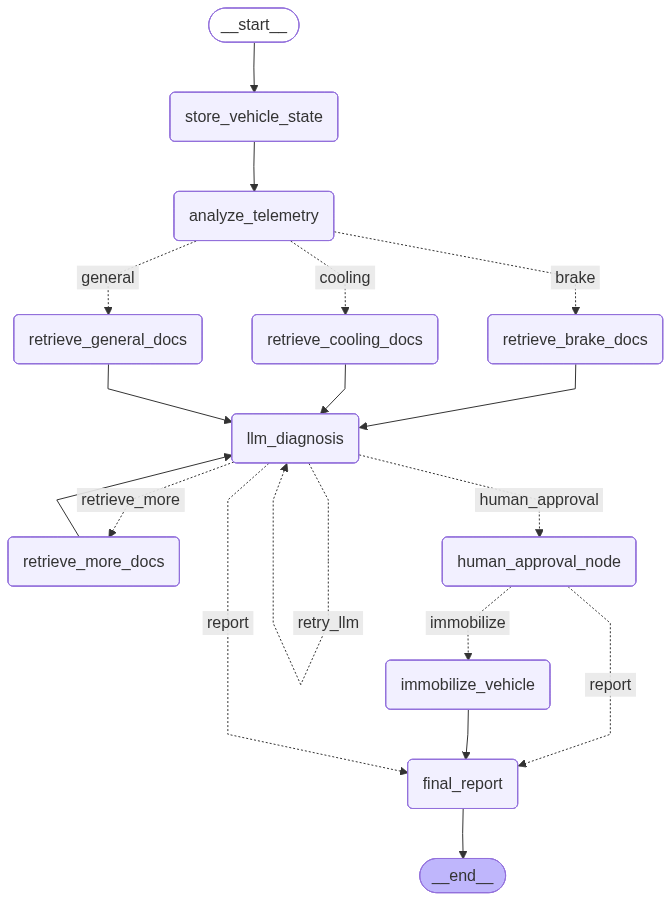

In [36]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))